In [9]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from coffea import util
from coffea.processor import accumulate
import os
import re
import pandas as pd
import hist
import matplotlib as mpl
import mplhep
import sys
import hist
import hist.intervals

sys.path.append("../analysisTools/")
import plotTools as ptools
import utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
f_sig = "../coffea/AllInOne_2022/Resolution.coffea"

sig_histo = util.load(f_sig) [0]


                                      mchi  dmchi  ctau    m1    m2  delta  \
sig_2022_Mchi-10p5_dMchi-1p0_ctau-10  10.5    1.0  10.0  10.0  11.0    0.1   

                                                                      name  
sig_2022_Mchi-10p5_dMchi-1p0_ctau-10  sig_2022_Mchi-10p5_dMchi-1p0_ctau-10  
                                     mchi  dmchi  ctau    m1    m2  delta  \
sig_2022_Mchi-11p0_dMchi-2p0_ctau-1  11.0    2.0   1.0  10.0  12.0    0.2   

                                                                    name  
sig_2022_Mchi-11p0_dMchi-2p0_ctau-1  sig_2022_Mchi-11p0_dMchi-2p0_ctau-1  
                                       mchi  dmchi   ctau    m1    m2  delta  \
sig_2022_Mchi-11p0_dMchi-2p0_ctau-100  11.0    2.0  100.0  10.0  12.0    0.2   

                                                                        name  
sig_2022_Mchi-11p0_dMchi-2p0_ctau-100  sig_2022_Mchi-11p0_dMchi-2p0_ctau-100  
                                     mchi  dmchi  ctau    m1    m

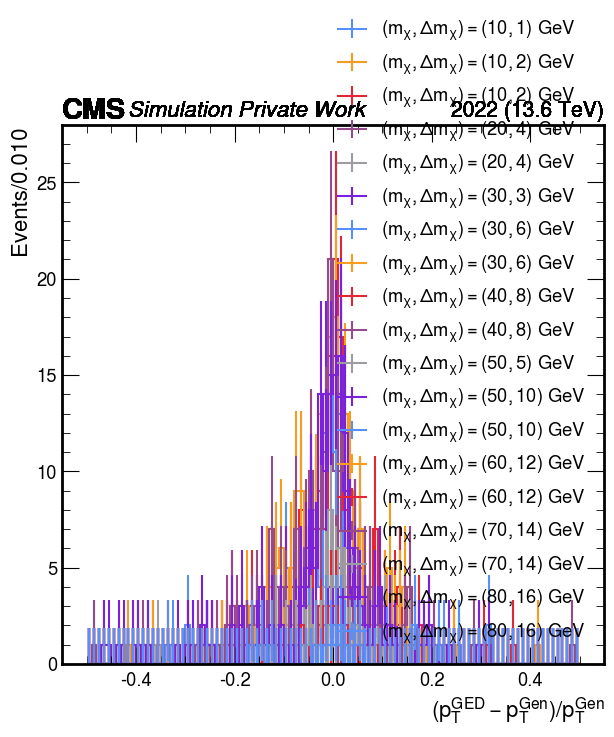

In [11]:
fig, ax = plt.subplots(figsize=(7,7))

# Plot settings
plot_dict = {
    'variable':'res_GED_gen',
    'cut': 'cut1',
    'year': 2022
}
style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': False, 
    'doLogx': False,
    'doDensity': False,
    'doYerr': True, 
    'xlabel': r'$(p_{T}^{\mathrm{GED}}-p_{T}^{\mathrm{Gen}})/p_{T}^{\mathrm{Gen}}$',
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': False,
    'outDir': './plots/signal_2018',
    'outName': f'gen_ele_vxy10_m110.png'
}
#signal points
samples = {
    10: 
    {
        0.1: [10],
        0.2: [1,100],
    },
    20: 
    {
        
        0.2: [1, 100],
    },
    30: 
    {
        0.1: [10],
        0.2: [1,100]
    },
    40: 
    {
        0.2: [1, 100],
    },
    50:
    {
        0.1: [10],
        0.2: [1,100],
    },
    60:
    {
         0.2: [1,100],
    },
    70:
    {
         0.2: [1,100],
    },
    80:
    {
         0.2: [1,100],
    }
 
}

h_list=[]
h_sum = 0

for m1,deltas in samples.items():
    for delta, ctaus in deltas.items():
        for ctau in ctaus:
            h = ptools.plot_signal_1D_return_histo(sig_histo, m1, delta, ctau, plot_dict, style_dict)
            h_list.append(h)
            h_sum=h_sum+h
            



/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


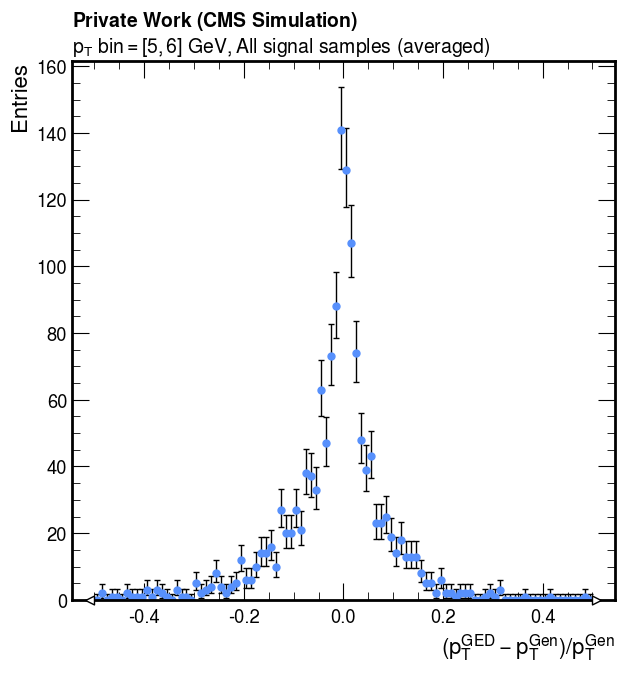

In [12]:
fig, ax = plt.subplots(figsize=(7,7))

mplhep.histplot(h_sum, histtype='errorbar',yerr=True, fmt='o', capsize=2, ecolor='black')
plt.xlabel(r'$(p_{T}^{\mathrm{GED}}-p_{T}^{\mathrm{Gen}})/p_{T}^{\mathrm{Gen}}$')
plt.ylabel("Entries")

plt.title(
    r"$\bf{Private\ Work\ (CMS\ Simulation)}$"
    "\n"
    r"$\mathrm{p_{T}\ bin = [5,6]\ GeV, All\ signal\ samples\ (averaged) }$",
    fontsize=14,
    loc="left",
)

plt.show()

                                      mchi  dmchi  ctau    m1    m2  delta  \
sig_2022_Mchi-10p5_dMchi-1p0_ctau-10  10.5    1.0  10.0  10.0  11.0    0.1   

                                                                      name  
sig_2022_Mchi-10p5_dMchi-1p0_ctau-10  sig_2022_Mchi-10p5_dMchi-1p0_ctau-10  
[0.005 0.01  0.015 0.02  0.025 0.03  0.035 0.04  0.045 0.05  0.055 0.06
 0.065 0.07  0.075 0.08  0.085 0.09  0.095 0.1   0.105 0.11  0.115 0.12
 0.125 0.13  0.135 0.14  0.145 0.15  0.155 0.16  0.165 0.17  0.175 0.18
 0.185 0.19  0.195 0.2   0.205 0.21  0.215 0.22  0.225 0.23  0.235 0.24
 0.245 0.25  0.255 0.26  0.265 0.27  0.275 0.28  0.285 0.29  0.295 0.3
 0.305 0.31  0.315 0.32  0.325 0.33  0.335 0.34  0.345 0.35  0.355 0.36
 0.365 0.37  0.375 0.38  0.385 0.39  0.395 0.4   0.405 0.41  0.415 0.42
 0.425 0.43  0.435 0.44  0.445 0.45  0.455 0.46  0.465 0.47  0.475 0.48
 0.485 0.49  0.495 0.5  ]
                                      mchi  dmchi  ctau    m1    m2  delta  \
sig_2022_M

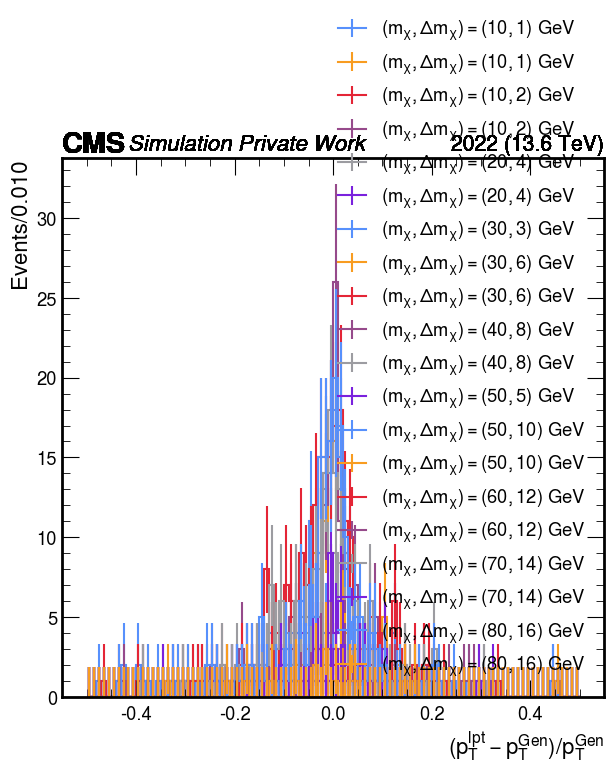

In [24]:
fig, ax = plt.subplots(figsize=(7,7))

# Plot settings
plot_dict = {
    'variable':'res_LPT_gen',
    'cut': 'cut1',
    'year': 2022
}
style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': False, 
    'doLogx': False,
    'doDensity': False,
    'doYerr': True, 
    'xlabel': r'$(p_{T}^{\mathrm{lpt}}-p_{T}^{\mathrm{Gen}})/p_{T}^{\mathrm{Gen}}$',
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': False,
    'outDir': './plots/signal_2018',
    'outName': f'gen_ele_vxy10_m110.png'
}
#signal points
samples = {
    10: 
    {
        0.1: [10],
        0.2: [1,100],
    },
    20: 
    {
        
        0.2: [1, 100],
    },
    30: 
    {
        0.1: [10],
        0.2: [1,100]
    },
    40: 
    {
        0.2: [1, 100],
    },
    50:
    {
        0.1: [10],
        0.2: [1,100],
    },
    60:
    {
         0.2: [1,100],
    },
    70:
    {
         0.2: [1,100],
    },
    80:
    {
         0.2: [1,100],
    }
 
}

h_list_lpt=[]
h_sum_lpt = 0

for m1,deltas in samples.items():
    for delta, ctaus in deltas.items():
        for ctau in ctaus:
            h_lpt = ptools.plot_signal_1D_return_histo(sig_histo, m1, delta, ctau, plot_dict, style_dict)
            h_list_lpt.append(h_lpt)
            h_sum_lpt=h_sum_lpt+h_lpt


In [59]:
counts = h_sum.values()
edges = h_sum.axes[0].edges

bin_x = (edges[1:]+edges[-1])/2

print (bin_x)

# print ("h_sum.variances()=", h_sum.variances())

[0.005 0.01  0.015 0.02  0.025 0.03  0.035 0.04  0.045 0.05  0.055 0.06
 0.065 0.07  0.075 0.08  0.085 0.09  0.095 0.1   0.105 0.11  0.115 0.12
 0.125 0.13  0.135 0.14  0.145 0.15  0.155 0.16  0.165 0.17  0.175 0.18
 0.185 0.19  0.195 0.2   0.205 0.21  0.215 0.22  0.225 0.23  0.235 0.24
 0.245 0.25  0.255 0.26  0.265 0.27  0.275 0.28  0.285 0.29  0.295 0.3
 0.305 0.31  0.315 0.32  0.325 0.33  0.335 0.34  0.345 0.35  0.355 0.36
 0.365 0.37  0.375 0.38  0.385 0.39  0.395 0.4   0.405 0.41  0.415 0.42
 0.425 0.43  0.435 0.44  0.445 0.45  0.455 0.46  0.465 0.47  0.475 0.48
 0.485 0.49  0.495 0.5  ]


/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


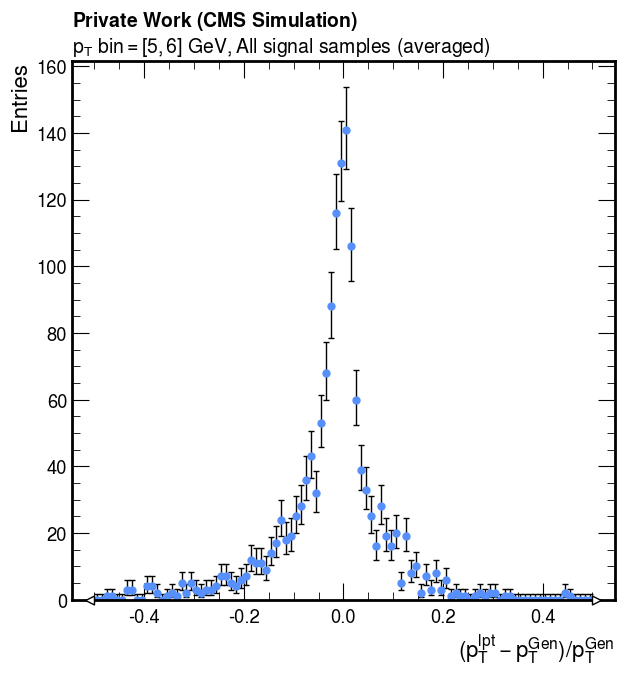

In [37]:
fig, ax = plt.subplots(figsize=(7,7))

mplhep.histplot(h_sum_lpt, histtype='errorbar',yerr=True, fmt='o', capsize=2, ecolor='black')
plt.xlabel(r'$(p_{T}^{\mathrm{lpt}}-p_{T}^{\mathrm{Gen}})/p_{T}^{\mathrm{Gen}}$')
plt.ylabel("Entries")

plt.title(
    r"$\bf{Private\ Work\ (CMS\ Simulation)}$"
    "\n"
    r"$\mathrm{p_{T}\ bin = [5,6]\ GeV, All\ signal\ samples\ (averaged) }$",
    fontsize=14,
    loc="left",
)

plt.show()

In [26]:
#1. Define your model

def double_cb(x,u,sig, nl, a_l, nr, a_r,N):
    t=(x-u)/(sig)
    al = abs(a_l)
    ar = abs(a_r)

    left_tail = t < -al
    core = (t>-al) & (t<ar)
    right_tail = t > ar

    y=np.empty_like(t)

    y[core] = np.exp(-0.5*t[core]*t[core])

    A_L = (nl / al)**nl * np.exp(-0.5 * al**2)
    B_L = (nl / al) - al
    y[left_tail] = A_L / (B_L - t[left_tail])**nl

    A_R = (nr / ar)**nr * np.exp(-0.5 * ar**2)
    B_R = (nr / ar) - ar
    y[right_tail] = A_R / (B_R + t[right_tail])**nr

    return N*y


/tmp/ipykernel_243337/3392158735.py:20: RuntimeWarning: invalid value encountered in scalar power
  A_R = (nr / ar)**nr * np.exp(-0.5 * ar**2)
/tmp/ipykernel_243337/3392158735.py:22: RuntimeWarning: invalid value encountered in power
  y[right_tail] = A_R / (B_R + t[right_tail])**nr
/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/scipy/optimize/_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


[-4.18437243e-03  1.01234680e-02  3.20000000e-01  3.43000000e+00
  2.18314218e-09  2.07463603e+00  1.05463229e+02]


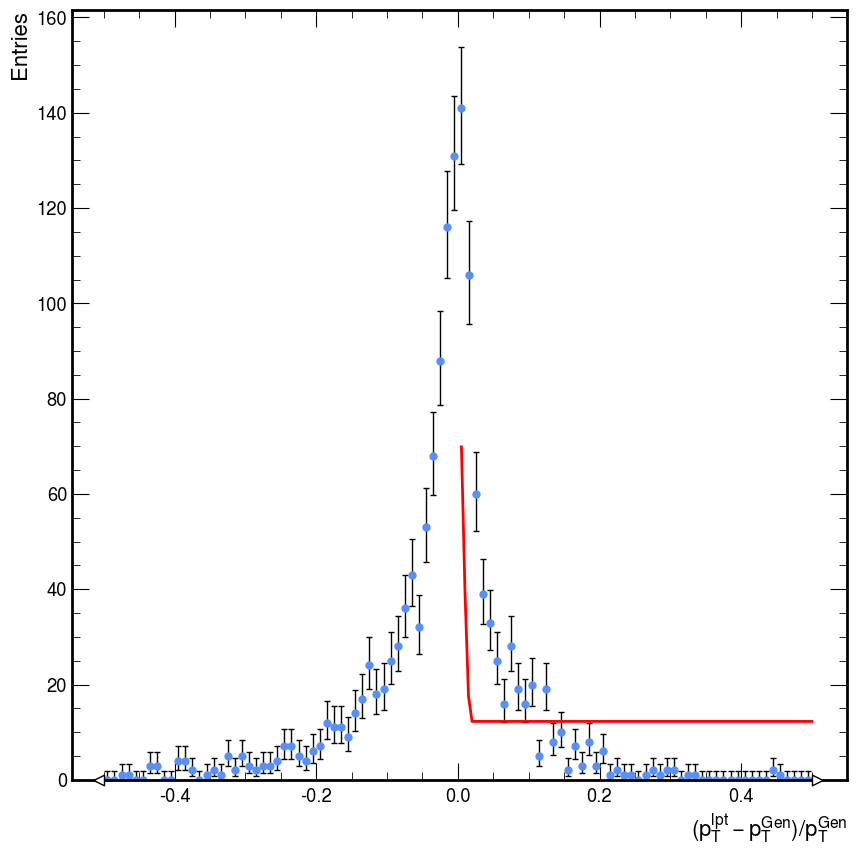

In [78]:
#2. Put your data

xdata = bin_x
ydata = counts

#3. Curve fit 
from scipy.optimize import curve_fit

initial_guess = [0.001, 0.013, 0.32, 3.43, 0.58, 2.60,147] #[mean, sigma, nl, al, nr, ar, N]

popt, pcov = curve_fit(double_cb, xdata, ydata, p0=initial_guess)

# plt.errorbar(xdata, ydata, fmt='o', capsize=2, ecolor='black')

mplhep.histplot(h_sum_lpt, histtype='errorbar',yerr=True, fmt='o', capsize=2, ecolor='black')

plt.plot(xdata, double_cb(xdata, *popt), label='Double Crystal Ball Fit', color='red', linewidth=2)


plt.xlabel(r'$(p_{T}^{\mathrm{lpt}}-p_{T}^{\mathrm{Gen}})/p_{T}^{\mathrm{Gen}}$')
plt.ylabel("Entries")

print (popt)
